# Demo - drawing and predicting digits

In [1]:
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import tkinter as tk
from PIL import Image, ImageDraw
import numpy as np

In [82]:
model = load_model('saved_model.keras')

## Image Visualization

In [83]:
def show_image(image, label):
    plt.figure(figsize=(4, 4))
    plt.title(f"{label} (28x28)")

    plt.imshow(image, cmap='gray')

    plt.axis("off")
    plt.show()

## Canvas

In [84]:
class DigitDrawer:
    def __init__(self):
        self.canvas_size = 280
        self.output_size = (28, 28)
        self.final_array = None

        self._image = Image.new("L", (self.canvas_size, self.canvas_size), 0)
        self._draw_context = ImageDraw.Draw(self._image)

    def draw(self):
        self.root = tk.Tk()
        self.root.title("Draw a Digit")

        self.canvas = tk.Canvas(self.root, width=self.canvas_size,
                                height=self.canvas_size, bg="black")
        self.canvas.pack()
        self.canvas.bind("<B1-Motion>", self._paint)

        btn_finish = tk.Button(self.root, text="Finish", command=self._finish)
        btn_finish.pack(fill=tk.X)

        self.root.mainloop()

    def _paint(self, event):
        r = 10  # Brush radius
        x1, y1 = (event.x - r), (event.y - r)
        x2, y2 = (event.x + r), (event.y + r)

        self.canvas.create_oval(x1, y1, x2, y2, fill="white", outline="white")
        self._draw_context.ellipse([x1, y1, x2, y2], fill=255)

    def _finish(self):
        # Resize to 28x28
        small_image = self._image.resize(self.output_size, resample=Image.Resampling.LANCZOS)
        self.final_array = np.array(small_image)

        self.root.destroy()

    def get(self):
        if self.final_array is None:
            print("Warning: No digit drawn yet. Call .draw() first.")
        return self.final_array

## Drawing and Prediction

In [85]:
def predict_number(my_digit):
    result = model.predict(my_digit)
    predicted_digit = np.argmax(result)
    return predicted_digit

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


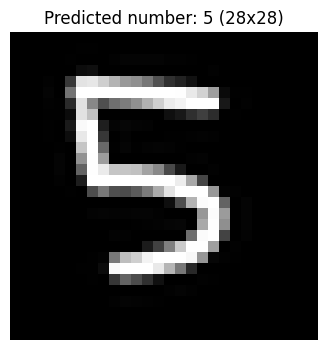

In [86]:
drawer = DigitDrawer()

drawer.draw()
my_digit = drawer.get()

if my_digit is not None:
    my_digit_processed = my_digit.astype('float32') / 255.0
    my_digit_processed = my_digit_processed.reshape(1, 28, 28, 1)

    digit_pred = predict_number(my_digit_processed)
    show_image(my_digit, f"Predicted number: {digit_pred}")